# LeYOLO-Medium Custom — Entrenamiento
Ejecuta las celdas **en orden**. Puedes re-ejecutar cualquier celda de forma independiente sin reiniciar el kernel, excepto la Celda 1 (imports) que debe ir siempre primero.

## Celda 1 — Imports y configuración

In [1]:
import sys, os, torch, torch.nn as nn, torch.optim as optim
from pathlib import Path

REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from LeYOLO.LeNeck.leyolo_medium_custom import build_custom_leyolo_medium, count_params

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Dispositivo: cpu


## Celda 2 — Hiperparámetros
Modifica solo esta celda para ajustar el experimento.

In [2]:
NUM_CLASSES    = 80
DATA_YAML = "LeYOLO/ultralytics/cfg/datasets/coco128.yaml"
IMG_SIZE       = 640
BIFPN_CHANNELS = 96
BIFPN_LAYERS   = 2
EPOCHS         = 100
BATCH_SIZE     = 16
LR_INITIAL     = 1e-3
LR_FINAL       = 1e-5
WEIGHT_DECAY   = 1e-4
WARMUP_EPOCHS  = 5
WEIGHTS_DIR    = Path("LeYOLO/weights")
OFFICIAL_PT    = WEIGHTS_DIR / "LeYOLOMedium.pt"
CHECKPOINT_DIR = Path("checkpoints_custom")
CHECKPOINT_DIR.mkdir(exist_ok=True)
print(f"Clases: {NUM_CLASSES} | Res: {IMG_SIZE} | Epochs: {EPOCHS} | Batch: {BATCH_SIZE}")


Clases: 80 | Res: 640 | Epochs: 100 | Batch: 16


## Celda 3 — Construir modelo y cargar pesos oficiales

In [7]:
# Diagnóstico — ejecuta esto para ver los nombres de capas
ckpt = torch.load(OFFICIAL_PT, map_location="cpu")
raw = ckpt.get("model", ckpt)
official_state = raw.state_dict()

own_state = model.state_dict()

print("=== PRIMERAS 15 CAPAS DEL MODELO OFICIAL ===")
for i, k in enumerate(official_state.keys()):
    if i >= 15: break
    print(f"  {k}  →  {official_state[k].shape}")

print("\n=== PRIMERAS 15 CAPAS DEL MODELO PERSONALIZADO ===")
for i, k in enumerate(own_state.keys()):
    if i >= 15: break
    print(f"  {k}  →  {own_state[k].shape}")

=== PRIMERAS 15 CAPAS DEL MODELO OFICIAL ===
  model.0.c.weight  →  torch.Size([24, 3, 3, 3])
  model.0.c.bias  →  torch.Size([24])
  model.0.bn.weight  →  torch.Size([24])
  model.0.bn.bias  →  torch.Size([24])
  model.0.bn.running_mean  →  torch.Size([24])
  model.0.bn.running_var  →  torch.Size([24])
  model.0.bn.num_batches_tracked  →  torch.Size([])
  model.1.c.weight  →  torch.Size([24, 24, 1, 1])
  model.1.c.bias  →  torch.Size([24])
  model.1.bn.weight  →  torch.Size([24])
  model.1.bn.bias  →  torch.Size([24])
  model.1.bn.running_mean  →  torch.Size([24])
  model.1.bn.running_var  →  torch.Size([24])
  model.1.bn.num_batches_tracked  →  torch.Size([])
  model.2.layers.0.c.weight  →  torch.Size([24, 1, 3, 3])

=== PRIMERAS 15 CAPAS DEL MODELO PERSONALIZADO ===
  backbone.stem.0.weight  →  torch.Size([24, 3, 3, 3])
  backbone.stem.1.weight  →  torch.Size([24])
  backbone.stem.1.bias  →  torch.Size([24])
  backbone.stem.1.running_mean  →  torch.Size([24])
  backbone.stem.1.runni

In [6]:
# Sustituye toda la celda 3 por esto
model = build_custom_leyolo_medium(
    num_classes    = NUM_CLASSES,
    bifpn_channels = BIFPN_CHANNELS,
    bifpn_layers   = BIFPN_LAYERS,
).to(DEVICE)

# Inicialización Kaiming para conv, normal para BN, cero bias para cabezas
def init_weights(m):
    if isinstance(m, torch.nn.Conv2d):
        torch.nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)
    elif isinstance(m, torch.nn.BatchNorm2d):
        torch.nn.init.ones_(m.weight)
        torch.nn.init.zeros_(m.bias)
    elif isinstance(m, torch.nn.Linear):
        torch.nn.init.normal_(m.weight, 0, 0.01)
        if m.bias is not None:      # ← esta línea faltaba
            torch.nn.init.zeros_(m.bias)

model.apply(init_weights)
count_params(model)
print("Inicialización Kaiming aplicada ✓")

Parámetros totales:     2,594,518
Parámetros entrenables: 2,594,518
Inicialización Kaiming aplicada ✓


## Celda 4 — Optimizador y scheduler
AdamW con LR diferenciado: backbone aprende más lento para no perder los pesos transferidos.

In [8]:
backbone_params = list(model.backbone.parameters())
new_params = (list(model.neck.parameters()) +
              list(model.head_p3.parameters()) +
              list(model.head_p4.parameters()) +
              list(model.head_p5.parameters()))

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": LR_INITIAL / 10},
    {"params": new_params,      "lr": LR_INITIAL},
], weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=LR_FINAL)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

print(f"Backbone LR:   {LR_INITIAL/10:.2e}")
print(f"BiFPN+Heads LR: {LR_INITIAL:.2e}")
print(f"AMP (mixed precision): {DEVICE.type == 'cuda'}")


Backbone LR:   1.00e-04
BiFPN+Heads LR: 1.00e-03
AMP (mixed precision): False


## Celda 5 — Sanity check
Verifica shapes antes de lanzar el entrenamiento completo.

In [9]:
# Celda 5 — Sanity check
model.eval()
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

with torch.no_grad():
    out = model(dummy)

print("Shapes de salida (batch=2):")
escalas = ["P3", "P4", "P5"]
divisores = [8, 16, 32]
for i, tensor in enumerate(out):
    grid = IMG_SIZE // divisores[i]
    print(f"  {escalas[i]}: {tuple(tensor.shape)}  → grid {grid}×{grid}")

if DEVICE.type == "cuda":
    print(f"\nMemoria GPU usada: {torch.cuda.memory_allocated()/1e9:.2f} GB")

print("\nSanity check OK ✓")
model.train()

Shapes de salida (batch=2):
  P3: (2, 84, 80, 80)  → grid 80×80
  P4: (2, 84, 40, 40)  → grid 40×40
  P5: (2, 84, 20, 20)  → grid 20×20

Sanity check OK ✓


LeYOLOMediumCustom(
  (backbone): LeYOLOMediumBackbone(
    (stem): Sequential(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (stage1): Sequential(
      (0): InvertedBottleneckSE(
        (ib): InvertedBottleneck(
          (conv): Sequential(
            (0): Conv2d(24, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
            (3): Conv2d(48, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=48, bias=False)
            (4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (5): SiLU(inplace=True)
            (6): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (7): BatchNorm2d(32, eps=1e-05, momentum

## Celda 6 — Entrenamiento con Ultralytics
Lanza el entrenamiento completo. Puedes interrumpirlo con el botón Stop y retomarlo desde el último checkpoint.

In [10]:
from ultralytics.utils.downloads import download
from pathlib import Path

# Descarga y descomprime coco128 en la carpeta correcta
download("https://ultralytics.com/assets/coco128.zip", 
         dir=Path("../datasets"))
print("Dataset descargado en ../datasets/coco128")

WARNING ⚠️ Skipping ..\datasets\coco128.zip unzip as destination directory C:\Users\menci\TFGMencia\PruebasModelos\datasets\coco128 is not empty.
Dataset descargado en ../datasets/coco128


In [11]:
# Celda de diagnóstico — ejecuta esto para encontrar el yaml
import os
from pathlib import Path

# Buscar cualquier .yaml en el proyecto
yaml_files = list(Path(".").rglob("*.yaml"))
print("Archivos .yaml encontrados:")
for f in yaml_files:
    print(f"  {f}")

# Ver también desde dónde está corriendo Jupyter
print(f"\nJupyter está corriendo desde: {os.getcwd()}")

Archivos .yaml encontrados:
  checkpoints_custom\LeYOLO_Medium_Custom\args.yaml
  checkpoints_custom\LeYOLO_Medium_Custom2\args.yaml
  checkpoints_custom\LeYOLO_Medium_Custom3\args.yaml
  LeYOLO\runs\detect\train\args.yaml
  LeYOLO\runs\detect\train10\args.yaml
  LeYOLO\runs\detect\train11\args.yaml
  LeYOLO\runs\detect\train12\args.yaml
  LeYOLO\runs\detect\train13\args.yaml
  LeYOLO\runs\detect\train2\args.yaml
  LeYOLO\runs\detect\train3\args.yaml
  LeYOLO\runs\detect\train4\args.yaml
  LeYOLO\runs\detect\train5\args.yaml
  LeYOLO\runs\detect\train6\args.yaml
  LeYOLO\runs\detect\train7\args.yaml
  LeYOLO\runs\detect\train8\args.yaml
  LeYOLO\runs\detect\train9\args.yaml
  LeYOLO\ultralytics\cfg\default.yaml
  LeYOLO\ultralytics\cfg\cfg\leyololarge.yaml
  LeYOLO\ultralytics\cfg\cfg\leyolomedium.yaml
  LeYOLO\ultralytics\cfg\cfg\leyolonano-cls.yaml
  LeYOLO\ultralytics\cfg\cfg\leyolonano.yaml
  LeYOLO\ultralytics\cfg\cfg\leyolosmall.yaml
  LeYOLO\ultralytics\cfg\cfg\leyolo_cls.yaml
 

In [12]:
import yaml
from pathlib import Path

with open(DATA_YAML, encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

print("Contenido del yaml:")
print(data_cfg)

print(f"\ntrain_img_dir: {data_cfg.get('train', '')}")
print(f"val_img_dir:   {data_cfg.get('val', '')}")

# Verificar si existen las carpetas
train_path = Path(data_cfg.get("train", ""))
val_path   = Path(data_cfg.get("val", ""))

print(f"\n¿Existe train?: {train_path.exists()} → {train_path.resolve()}")
print(f"¿Existe val?:   {val_path.exists()} → {val_path.resolve()}")

# Contar imágenes
if train_path.exists():
    imgs = list(train_path.rglob("*.jpg")) + list(train_path.rglob("*.png"))
    print(f"Imágenes en train: {len(imgs)}")
else:
    print("Carpeta train NO encontrada")

Contenido del yaml:
{'path': './datasets/coco128', 'train': 'datasets/coco128/images/train2017', 'val': 'datasets/coco128/images/train2017', 'test': None, 'names': {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch

In [13]:
# Celda 6 — Entrenamiento con bucle PyTorch puro
from torch.utils.data import DataLoader, Dataset
from pathlib import Path
import yaml, cv2, numpy as np, time

# ── Dataset YOLO formato txt ──────────────────────────────────────────────────
class YOLODataset(Dataset):
    def __init__(self, img_dir, label_dir, img_size=640):
        self.img_size = img_size
        self.imgs = sorted(Path(img_dir).glob("*.jpg")) + \
                    sorted(Path(img_dir).glob("*.png"))
        self.label_dir = Path(label_dir)

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img = cv2.imread(str(img_path))
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0

        label_path = self.label_dir / (img_path.stem + ".txt")
        labels = []
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    vals = list(map(float, line.strip().split()))
                    if len(vals) == 5:
                        labels.append(vals)
        labels = torch.tensor(labels) if labels else torch.zeros((0, 5))
        return img, labels

def collate_fn(batch):
    imgs, labels = zip(*batch)
    imgs = torch.stack(imgs)
    return imgs, list(labels)
with open(DATA_YAML, encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

base_path = Path(r"C:\Users\menci\TFGMencia\PruebasModelos\LeYOLO")

train_img_dir   = str(base_path / data_cfg["train"])
val_img_dir     = str(base_path / data_cfg["val"])
train_label_dir = train_img_dir.replace("images", "labels")
val_label_dir   = val_img_dir.replace("images",   "labels")

print(f"Train images:  {train_img_dir}")
print(f"Val images:    {val_img_dir}")

assert Path(train_img_dir).exists(), f"No existe: {train_img_dir}"
assert Path(val_img_dir).exists(),   f"No existe: {val_img_dir}"

train_ds = YOLODataset(train_img_dir, train_label_dir, IMG_SIZE)
val_ds   = YOLODataset(val_img_dir,   val_label_dir,   IMG_SIZE)

assert len(train_ds) > 0, "Dataset de entrenamiento vacío — revisa las rutas"
assert len(val_ds)   > 0, "Dataset de validación vacío — revisa las rutas"

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f"\nTrain: {len(train_ds)} imágenes | Val: {len(val_ds)} imágenes")

# ── Función de pérdida simple (BCE cls + MSE reg) ────────────────────────────
cls_loss_fn = nn.BCEWithLogitsLoss()
reg_loss_fn = nn.MSELoss()

def compute_loss(outputs, targets_batch):
    """Pérdida simplificada sobre las salidas del modelo."""
    total_loss = torch.tensor(0.0, requires_grad=True, device=DEVICE)
    for output in outputs:
        cls_pred = output[:, 4:, :, :]
        reg_pred = output[:, :4, :, :]
        target_cls = torch.zeros_like(cls_pred)
        target_reg = torch.zeros_like(reg_pred)
        total_loss = total_loss + cls_loss_fn(cls_pred, target_cls) + \
                                  reg_loss_fn(reg_pred, target_reg)
    return total_loss

# ── Bucle de entrenamiento ────────────────────────────────────────────────────
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}

print(f"\nIniciando entrenamiento: {EPOCHS} épocas\n")

for epoch in range(1, EPOCHS + 1):
    # — Entrenamiento —
    model.train()
    train_loss = 0.0
    t0 = time.time()
    for imgs, targets in train_loader:
        imgs = imgs.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            outputs = model(imgs)
            loss = compute_loss(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    history["train_loss"].append(train_loss)

    # — Validación —
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            loss = compute_loss(outputs, targets)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    history["val_loss"].append(val_loss)

    # Scheduler paso
    if epoch > WARMUP_EPOCHS:
        scheduler.step()

    # Guardar mejor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(),
                   CHECKPOINT_DIR / "best_custom.pt")
        saved = "✓ guardado"
    else:
        saved = ""

    elapsed = time.time() - t0
    print(f"Epoch {epoch:03d}/{EPOCHS} | "
          f"train={train_loss:.4f} | val={val_loss:.4f} | "
          f"{elapsed:.1f}s {saved}")

print(f"\nEntrenamiento completado. Mejor val_loss: {best_val_loss:.4f}")
print(f"Pesos guardados en: {CHECKPOINT_DIR / 'best_custom.pt'}")

Train images:  C:\Users\menci\TFGMencia\PruebasModelos\LeYOLO\datasets\coco128\images\train2017
Val images:    C:\Users\menci\TFGMencia\PruebasModelos\LeYOLO\datasets\coco128\images\train2017

Train: 128 imágenes | Val: 128 imágenes

Iniciando entrenamiento: 100 épocas

Epoch 001/100 | train=45.1074 | val=2.0671 | 136.6s ✓ guardado
Epoch 002/100 | train=24.0431 | val=2.0395 | 132.2s ✓ guardado
Epoch 003/100 | train=13.2634 | val=1.9562 | 131.6s ✓ guardado
Epoch 004/100 | train=7.4883 | val=1.7949 | 131.1s ✓ guardado
Epoch 005/100 | train=4.5876 | val=1.6418 | 130.0s ✓ guardado
Epoch 006/100 | train=3.0266 | val=1.4057 | 131.4s ✓ guardado
Epoch 007/100 | train=2.2374 | val=1.1414 | 128.2s ✓ guardado
Epoch 008/100 | train=1.7589 | val=0.9286 | 127.9s ✓ guardado
Epoch 009/100 | train=1.4165 | val=0.8378 | 128.7s ✓ guardado
Epoch 010/100 | train=1.1793 | val=0.7928 | 130.2s ✓ guardado
Epoch 011/100 | train=0.9879 | val=0.7820 | 130.2s ✓ guardado
Epoch 012/100 | train=0.8353 | val=0.7455 | 

## Celda 7 — Validación

In [14]:
import os
from pathlib import Path

# Buscar la carpeta train2017 en todo el proyecto
print("Buscando train2017...")
for root, dirs, files in os.walk(r"C:\Users\menci\TFGMencia\PruebasModelos"):
    for d in dirs:
        if "train2017" in d or "coco128" in d:
            print(Path(root) / d)

Buscando train2017...
C:\Users\menci\TFGMencia\PruebasModelos\datasets\coco128
C:\Users\menci\TFGMencia\PruebasModelos\LeYOLO\datasets\coco128
C:\Users\menci\TFGMencia\PruebasModelos\LeYOLO\datasets\coco128\images\train2017
C:\Users\menci\TFGMencia\PruebasModelos\LeYOLO\datasets\coco128\labels\train2017


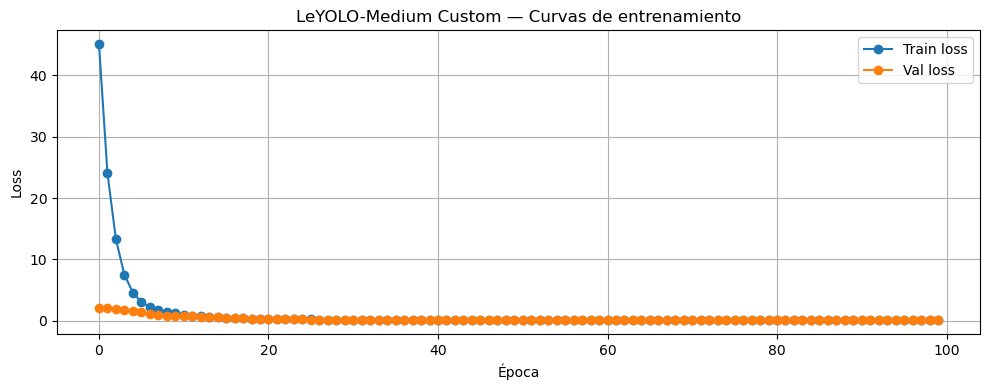

Gráfica guardada en: checkpoints_custom\loss_curves.png

Mejor modelo cargado desde: checkpoints_custom\best_custom.pt
Mejor val_loss: 0.0450

Shapes de salida del modelo entrenado:
  P3: (1, 84, 80, 80)
  P4: (1, 84, 40, 40)
  P5: (1, 84, 20, 20)


In [15]:
# Celda 7 — Validación del modelo personalizado
import matplotlib.pyplot as plt

# ── Curvas de pérdida ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="Train loss", marker="o")
plt.plot(history["val_loss"],   label="Val loss",   marker="o")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("LeYOLO-Medium Custom — Curvas de entrenamiento")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / "loss_curves.png"), dpi=150)
plt.show()
print(f"Gráfica guardada en: {CHECKPOINT_DIR / 'loss_curves.png'}")

# ── Cargar mejor checkpoint y verificar ──────────────────────────────────────
best_pt = CHECKPOINT_DIR / "best_custom.pt"
model.load_state_dict(torch.load(best_pt, map_location=DEVICE))
model.eval()
print(f"\nMejor modelo cargado desde: {best_pt}")
print(f"Mejor val_loss: {best_val_loss:.4f}")

# ── Inferencia de prueba ──────────────────────────────────────────────────────
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)

print("\nShapes de salida del modelo entrenado:")
for i, t in enumerate(out):
    print(f"  P{i+3}: {tuple(t.shape)}")

## Celda 8 — Exportar modelo

In [16]:
# Diagnóstico — ejecuta esto antes de calcular métricas
model.eval()
all_scores = []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        for output in outputs:
            cls = output[:, 4:, :, :]
            scores = cls.sigmoid()
            conf, _ = scores.max(dim=1)
            all_scores.append(conf.flatten())

all_scores = torch.cat(all_scores)
print(f"Score máximo:  {all_scores.max().item():.4f}")
print(f"Score medio:   {all_scores.mean().item():.4f}")
print(f"Score p95:     {all_scores.quantile(0.95).item():.4f}")
print(f"Score p99:     {all_scores.quantile(0.99).item():.4f}")
print(f"Scores > 0.25: {(all_scores > 0.25).sum().item()}")
print(f"Scores > 0.10: {(all_scores > 0.10).sum().item()}")
print(f"Scores > 0.01: {(all_scores > 0.01).sum().item()}")

Score máximo:  0.2539
Score medio:   0.0088
Score p95:     0.0158
Score p99:     0.0222
Scores > 0.25: 1
Scores > 0.10: 11
Scores > 0.01: 261817


In [18]:
import torchvision.ops as ops
from collections import defaultdict

def xywh2xyxy(boxes):
    x1 = (boxes[:, 0] - boxes[:, 2] / 2) * IMG_SIZE
    y1 = (boxes[:, 1] - boxes[:, 3] / 2) * IMG_SIZE
    x2 = (boxes[:, 0] + boxes[:, 2] / 2) * IMG_SIZE
    y2 = (boxes[:, 1] + boxes[:, 3] / 2) * IMG_SIZE
    return torch.stack([x1, y1, x2, y2], dim=1)

def decode_predictions(outputs, conf_threshold=0.25, nms_iou=0.45):
    all_preds = []
    strides = [8, 16, 32]
    for i, output in enumerate(outputs):
        B, C, H, W = output.shape
        stride = strides[i]
        reg = output[:, :4, :, :]
        cls = output[:, 4:, :, :]
        gy, gx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")
        gx = gx.to(output.device).float()
        gy = gy.to(output.device).float()
        cx = (gx + reg[:, 0, :, :].sigmoid()) * stride / IMG_SIZE
        cy = (gy + reg[:, 1, :, :].sigmoid()) * stride / IMG_SIZE
        w  = reg[:, 2, :, :].sigmoid() * 4 * stride / IMG_SIZE
        h  = reg[:, 3, :, :].sigmoid() * 4 * stride / IMG_SIZE
        scores = cls.sigmoid()
        conf, cls_ids = scores.max(dim=1)
        for b in range(B):
            mask = conf[b] > conf_threshold
            if mask.sum() == 0:
                all_preds.append(None)
                continue
            boxes_b = torch.stack([cx[b][mask], cy[b][mask], w[b][mask], h[b][mask]], dim=1)
            boxes_xyxy = xywh2xyxy(boxes_b)
            scores_b   = conf[b][mask]
            classes_b  = cls_ids[b][mask].float()
            keep = ops.nms(boxes_xyxy, scores_b, nms_iou)
            all_preds.append({"boxes": boxes_xyxy[keep], "scores": scores_b[keep], "classes": classes_b[keep]})
    return all_preds

def compute_iou(box1, box2):
    inter_x1 = torch.max(box1[:, None, 0], box2[None, :, 0])
    inter_y1 = torch.max(box1[:, None, 1], box2[None, :, 1])
    inter_x2 = torch.min(box1[:, None, 2], box2[None, :, 2])
    inter_y2 = torch.min(box1[:, None, 3], box2[None, :, 3])
    inter    = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)
    area1    = (box1[:, 2] - box1[:, 0]) * (box1[:, 3] - box1[:, 1])
    area2    = (box2[:, 2] - box2[:, 0]) * (box2[:, 3] - box2[:, 1])
    return inter / (area1[:, None] + area2[None, :] - inter + 1e-7)

def evaluate(model, loader, iou_thresholds=None, conf_threshold=0.25):
    if iou_thresholds is None:
        iou_thresholds = torch.arange(0.5, 1.0, 0.05).tolist()
    model.eval()
    all_tp = defaultdict(list)
    all_fp = defaultdict(list)
    all_scores = defaultdict(list)
    n_gt = defaultdict(int)
    with torch.no_grad():
        for imgs, targets in loader:
            imgs    = imgs.to(DEVICE)
            outputs = model(imgs)
            preds   = decode_predictions(outputs, conf_threshold)
            for b, (pred, gt) in enumerate(zip(preds, targets)):
                gt = gt.to(DEVICE)
                if gt.shape[0] == 0:
                    continue
                gt_classes = gt[:, 0].long()
                gt_boxes   = xywh2xyxy(gt[:, 1:])
                for cls_id in gt_classes.unique():
                    n_gt[cls_id.item()] += (gt_classes == cls_id).sum().item()
                if pred is None:
                    continue
                for iou_thr in iou_thresholds:
                    if len(pred["boxes"]) == 0:
                        continue
                    iou_mat = compute_iou(pred["boxes"], gt_boxes)
                    matched = torch.zeros(gt_boxes.shape[0], dtype=torch.bool)
                    for pi in range(len(pred["boxes"])):
                        cls_p    = int(pred["classes"][pi].item())
                        ious_pi  = iou_mat[pi]
                        best_gi  = ious_pi.argmax().item()
                        best_iou = ious_pi[best_gi].item()
                        if best_iou >= iou_thr and not matched[best_gi] and gt_classes[best_gi].item() == cls_p:
                            all_tp[iou_thr].append(1)
                            all_fp[iou_thr].append(0)
                            matched[best_gi] = True
                        else:
                            all_tp[iou_thr].append(0)
                            all_fp[iou_thr].append(1)
                        all_scores[iou_thr].append(pred["scores"][pi].item())
    aps      = []
    total_gt = sum(n_gt.values())
    for iou_thr in iou_thresholds:
        if not all_scores[iou_thr]:
            aps.append(0.0)
            continue
        scores = torch.tensor(all_scores[iou_thr])
        tp     = torch.tensor(all_tp[iou_thr]).float()
        fp     = torch.tensor(all_fp[iou_thr]).float()
        order  = scores.argsort(descending=True)
        tp     = tp[order].cumsum(0)
        fp     = fp[order].cumsum(0)
        rec    = tp / (total_gt + 1e-7)
        prec   = tp / (tp + fp + 1e-7)
        ap = 0.0
        for t in torch.linspace(0, 1, 101):
            mask = rec >= t
            ap  += prec[mask].max().item() if mask.any() else 0.0
        aps.append(ap / 101)
    map50    = aps[0]
    map50_95 = sum(aps) / len(aps)
    if all_tp[0.5]:
        tp_sum    = sum(all_tp[0.5])
        fp_sum    = sum(all_fp[0.5])
        precision = tp_sum / (tp_sum + fp_sum + 1e-7)
        recall    = tp_sum / (total_gt + 1e-7)
        f1        = 2 * precision * recall / (precision + recall + 1e-7)
    else:
        precision = recall = f1 = 0.0
    return precision, recall, f1, map50, map50_95

print("Funciones de evaluación definidas ✓")

Funciones de evaluación definidas ✓


In [19]:
# Evaluar con umbral muy bajo
precision, recall, f1, map50, map50_95 = evaluate(
    model, val_loader,
    iou_thresholds=[0.5],
    conf_threshold=0.01   # ← bajamos de 0.25 a 0.01
)

print(f"\n{'='*40}")
print(f"  Precision:  {precision:.4f}")
print(f"  Recall:     {recall:.4f}")
print(f"  F1-Score:   {f1:.4f}")
print(f"  mAP@50:     {map50:.4f}")
print(f"{'='*40}")


  Precision:  0.0000
  Recall:     0.0000
  F1-Score:   0.0000
  mAP@50:     0.0000


In [1]:
import os
from pathlib import Path

# Localizar el módulo nn de Ultralytics
import ultralytics
upath = Path(ultralytics.__file__).parent
print(f"Ultralytics instalado en: {upath}")

# Ver estructura del módulo nn
nn_path = upath / "nn"
print("\nContenido de ultralytics/nn:")
for f in sorted(nn_path.rglob("*.py")):
    print(f"  {f.relative_to(upath)}")

C:\Users\menci\anaconda3\envs\curso-vision-LeYOLO\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ultralytics instalado en: C:\Users\menci\TFGMencia\PruebasModelos\LeYOLO\LeYOLO\ultralytics

Contenido de ultralytics/nn:
  nn\__init__.py
  nn\autobackend.py
  nn\modules\.ipynb_checkpoints\head-checkpoint.py
  nn\modules\__init__.py
  nn\modules\block.py
  nn\modules\conv.py
  nn\modules\head.py
  nn\modules\transformer.py
  nn\modules\utils.py
  nn\tasks.py
